# Gas Sensor Drift & Abnormal Trend Monitor

A retrospective screening analysis of UCI Air Quality. Flags mark **items for investigation**, never proof of device failure.

The dataset has hourly records from five metal-oxide sensor responses, reference-analyzer measurements and weather context. UCI documents sensor/concept drift and marks missing readings with -200. Sensor responses and analyzer concentrations have different units and behavior, so independently median-indexed trends are used only for directional comparison.

**Data limit:** no maintenance, calibration, sensor age, alarm or repair history is supplied. All proposed maintenance fields below are recommendations, not records from this dataset. UCI lists research use only and excludes commercial purposes. [Dataset page](https://archive.ics.uci.edu/dataset/360/air%2Bquality) · DOI [10.24432/C59K5F](https://doi.org/10.24432/C59K5F).

## 1. Cleaning

The source CSV uses day/month/year, HH.MM.SS, semicolons and decimal commas. The timestamp is parsed, rows are sorted, and each -200 sentinel becomes a missing value. Values are left missing rather than imputed.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import SVG, display

ROOT = Path.cwd()
if not (ROOT / 'data/raw/AirQualityUCI.csv').exists():
    ROOT = ROOT.parent
raw = pd.read_csv(ROOT / 'data/raw/AirQualityUCI.csv', sep=';', decimal=',', na_values=[-200])
raw = raw.loc[:, ~raw.columns.astype(str).str.startswith('Unnamed')]
raw['Timestamp'] = pd.to_datetime(raw['Date'].astype(str).str.strip() + ' ' + raw['Time'].astype(str).str.strip(), format='%d/%m/%Y %H.%M.%S', errors='coerce')
raw = raw.drop(columns=['Date','Time']).dropna(subset=['Timestamp']).sort_values('Timestamp').reset_index(drop=True)
NUMERIC_CHANNELS = [c for c in raw.columns if c != 'Timestamp']
for c in NUMERIC_CHANNELS:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')
clean = raw
clean.head()

Timestamp,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT),T,RH,AH
2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,2.6,150.0,11.9,166.0,113.0,13.6,48.9,0.7578
2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,2.0,112.0,9.4,103.0,92.0,13.3,47.7,0.7255
2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,2.2,88.0,9.0,131.0,114.0,11.9,54.0,0.7502
2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,2.2,80.0,9.2,172.0,122.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,1.6,51.0,6.5,131.0,116.0,11.2,59.6,0.7888


## 2. Missing data and coverage

Rates use the full number of hourly rows as the denominator. Long gaps reduce rolling-window coverage. Missing observations are not filled.

In [2]:
quality_summary = pd.read_csv(ROOT / 'PowerBI/ChannelQuality.csv')
quality_summary[['SensorChannel','ReferenceChannel','SensorMissingRatePct','SensorPointFlags','DriftCandidateHours']].head(5)

Sensor,Reference,Sensor missing rate,Point flags,Drift candidate hours
PT08.S1(CO),CO(GT),3.9%,128,364
PT08.S2(NMHC),NMHC(GT),3.9%,122,0
PT08.S3(NOx),NOx(GT),3.9%,254,0
PT08.S4(NO2),NO2(GT),3.9%,219,586
PT08.S5(O3),—,3.9%,187,0


## 3. Point and sustained divergence flags

Point readings use a trailing 24-hour rolling median and median absolute deviation (MAD). Robust score = (reading − rolling median) / (1.4826 × rolling MAD). Values above absolute score 3.5 are flagged when at least 12 valid hourly readings are available.

For the four sensors with a paired reference, each series is indexed to its own study-period median (=100). A trailing 7-day rolling average of the difference is scored against that pair's robust distribution. A sustained divergence candidate requires absolute score above 2.5 for at least 72 hours in a 7-day window. The lower threshold applies to a smoothed signal and still requires three days of persistence. This is an exploratory retrospective rule; weather, cross-sensitivity and analyzer behavior can also affect it. PT08.S5(O3) has no matching reference channel.

In [3]:
monitoring = pd.read_csv(ROOT / 'PowerBI/SensorMonitoring.csv', parse_dates=['Timestamp'])
point_counts = monitoring.groupby('SensorChannel')[['SensorPointFlag','ReferencePointFlag','DriftCandidate']].sum()
point_counts

,SensorPointFlag,ReferencePointFlag,DriftCandidate
SensorChannel,,,
PT08.S1(CO),128,75,364
PT08.S2(NMHC),122,41,0
PT08.S3(NOx),254,13,0
PT08.S4(NO2),219,7,586
PT08.S5(O3),187,0,0


## 4. Trend and weather context

A value of 100 means the channel's median for this study period. It does not convert sensor response into analyzer units. Use reference and weather movement as context when reviewing any flag.

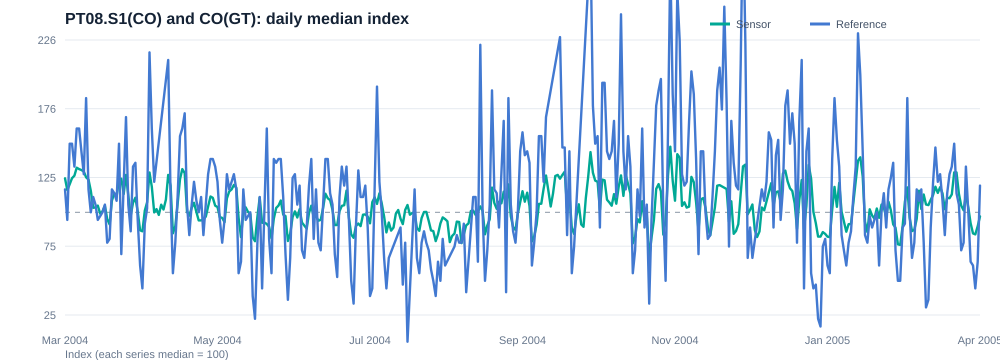

In [4]:
def make_daily_index_chart(monitoring, sensor_channel):
    part = monitoring.loc[monitoring['SensorChannel'] == sensor_channel].copy()
    part['Day'] = pd.to_datetime(part['Timestamp']).dt.floor('D')
    daily = part.groupby('Day').agg(sensor=('SensorIndex100','median'), reference=('ReferenceIndex100','median')).reset_index()
    # Sensor and analyzer concentrations use different units; their normalized indices compare direction only.
    import matplotlib.pyplot as plt
    ax = daily.plot(x='Day', y=['sensor','reference'], figsize=(12,4), color=['#00a895','#4279d1'])
    ax.set_ylabel('Index (each series median = 100)')
    ax.set_title(sensor_channel + ' and paired reference: daily median')
    ax.grid(alpha=.2)
    plt.show()

make_daily_index_chart(monitoring, 'PT08.S1(CO)')

## 5. Flagged periods

Contiguous flagged hours are grouped for review. The event export includes start/end, duration, peak robust score and mean temperature and humidity.

In [5]:
events = pd.read_csv(ROOT / 'PowerBI/InvestigationEvents.csv', parse_dates=['StartTime','EndTime'])
print(f'{len(events):,} grouped candidate periods')

577 grouped candidate periods


## 6. Proposed maintenance data to collect

Join future records by stable AssetID and sensor/channel: sensor model and serial, installation/commissioning date, sensor age, last calibration date/result, calibration gas or standard and certificate, alarm code/time, inspection finding, repair or replacement action, parts used, technician, service completion time, and post-maintenance verification result. Keep the record source and timestamps auditable. Do not populate these fields from this dataset.

## 7. Power BI handoff

Import PowerBI/SensorMonitoring.csv, PowerBI/ChannelQuality.csv and PowerBI/InvestigationEvents.csv. See Measures.dax and PowerBI_Dashboard_Guide.md for a proposed report page. GasSensorDriftDashboard.html is a self-contained interactive preview.